# Text Embedding and Visualization
This notebook demonstrates tokenization, padding, word embeddings, flattening, and PCA visualization of text data.

Arnav Narula 2547115 Lab 3 

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

I0000 00:00:1790750230.781873  306907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790750230.884561  306907 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790750232.315151  306907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset

In [2]:
dataset = [
    "The product quality is excellent",
    "I really love this product",
    "The quality of this item is amazing",
    "The product performance is poor",
    "I dislike this product completely"
]

print("--- Original Dataset ---")
for doc in dataset:
    print(doc)

--- Original Dataset ---
The product quality is excellent
I really love this product
The quality of this item is amazing
The product performance is poor
I dislike this product completely


### 1 & 2. Pre-process, create vocabulary, and assign Token IDs

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(dataset)
word_index = tokenizer.word_index

print("\n--- 1 & 2. Vocabulary with Token IDs ---")
print(word_index)


--- 1 & 2. Vocabulary with Token IDs ---
{'product': 1, 'the': 2, 'is': 3, 'this': 4, 'quality': 5, 'i': 6, 'excellent': 7, 'really': 8, 'love': 9, 'of': 10, 'item': 11, 'amazing': 12, 'performance': 13, 'poor': 14, 'dislike': 15, 'completely': 16}


### 3. Convert sentences into sequences of token IDs

In [4]:
sequences = tokenizer.texts_to_sequences(dataset)
print("\n--- 3. Token Sequences ---")
for seq in sequences:
    print(seq)


--- 3. Token Sequences ---
[2, 1, 5, 3, 7]
[6, 8, 9, 4, 1]
[2, 5, 10, 4, 11, 3, 12]
[2, 1, 13, 3, 14]
[6, 15, 4, 1, 16]


### 4. Apply padding

In [5]:
max_length = max([len(seq) for seq in sequences])
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

print("\n--- 4. Padded Token Sequences ---")
print(padded_sequences)


--- 4. Padded Token Sequences ---
[[ 2  1  5  3  7  0  0]
 [ 6  8  9  4  1  0  0]
 [ 2  5 10  4 11  3 12]
 [ 2  1 13  3 14  0  0]
 [ 6 15  4  1 16  0  0]]


### 5 & 6. Generate and display Word Embeddings

In [6]:
vocab_size = len(word_index) + 1  # +1 is for the padding token (0)
embedding_dim = 4 # Choosing a 4-dimensional vector representation for simplicity

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

embeddings = model.predict(padded_sequences)

print("\n--- 5 & 6. Word Embedding Representations ---")
print(f"Shape of embeddings: {embeddings.shape} (batch_size, sequence_length, embedding_dim)")
print("Embedding matrix for the first sentence:")
print(embeddings[0])

/home/arden/Coding/AMI_Classwork/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1790750236.554906  306907 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step

--- 5 & 6. Word Embedding Representations ---
Shape of embeddings: (5, 7, 4) (batch_size, sequence_length, embedding_dim)
Embedding matrix for the first sentence:
[[ 0.02178614  0.00280209 -0.03630181 -0.04602698]
 [ 0.03854169 -0.04684976  0.00954441  0.02098553]
 [-0.02608933  0.04325866 -0.04119219 -0.04005455]
 [-0.03891714 -0.03450868 -0.03601665  0.02494976]
 [-0.04226708  0.03905675  0.02503994 -0.00386601]
 [ 0.01045643 -0.04122232  0.02367796 -0.01247513]
 [ 0.01045643 -0.04122232  0.02367796 -0.01247513]]


### 7. Flatten the vector representations

In [7]:
model_flatten = Sequential()
model_flatten.add(model.layers[0])
model_flatten.add(Flatten())

flattened_vectors = model_flatten.predict(padded_sequences)
print("\n--- 7. Flattened Vector Representation ---")
print(f"Shape of flattened vectors: {flattened_vectors.shape} (batch_size, sequence_length * embedding_dim)")
for i, flat_vec in enumerate(flattened_vectors):
    print(f"Sentence {i+1} Flattened Vector: \n{flat_vec}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

--- 7. Flattened Vector Representation ---
Shape of flattened vectors: (5, 28) (batch_size, sequence_length * embedding_dim)
Sentence 1 Flattened Vector: 
[ 0.02178614  0.00280209 -0.03630181 -0.04602698  0.03854169 -0.04684976
  0.00954441  0.02098553 -0.02608933  0.04325866 -0.04119219 -0.04005455
 -0.03891714 -0.03450868 -0.03601665  0.02494976 -0.04226708  0.03905675
  0.02503994 -0.00386601  0.01045643 -0.04122232  0.02367796 -0.01247513
  0.01045643 -0.04122232  0.02367796 -0.01247513]
Sentence 2 Flattened Vector: 
[ 0.03195382  0.00974328  0.00723616 -0.0107432  -0.02244834  0.00246229
 -0.02430697  0.00481079 -0.00092683  0.00041299  0.02340135 -0.01197062
 -0.00384177  0.00307003 -0.01550704  0.02361146  0.03854169 -0.04684976
  0.00954441  0.02098553  0.01045643 -0.04122232  0.02367796 -0.01247513
  0.01045643 -0.04122232  0.02367796 -0.01247513]
Sentence 3 Flattened Vector: 
[ 0.02178614  0.00280209 -0.03630181 -0.04602698 -0.02608933  

### 8. Visualize word embeddings using PCA


--- 8. Plotting PCA Visualization ---


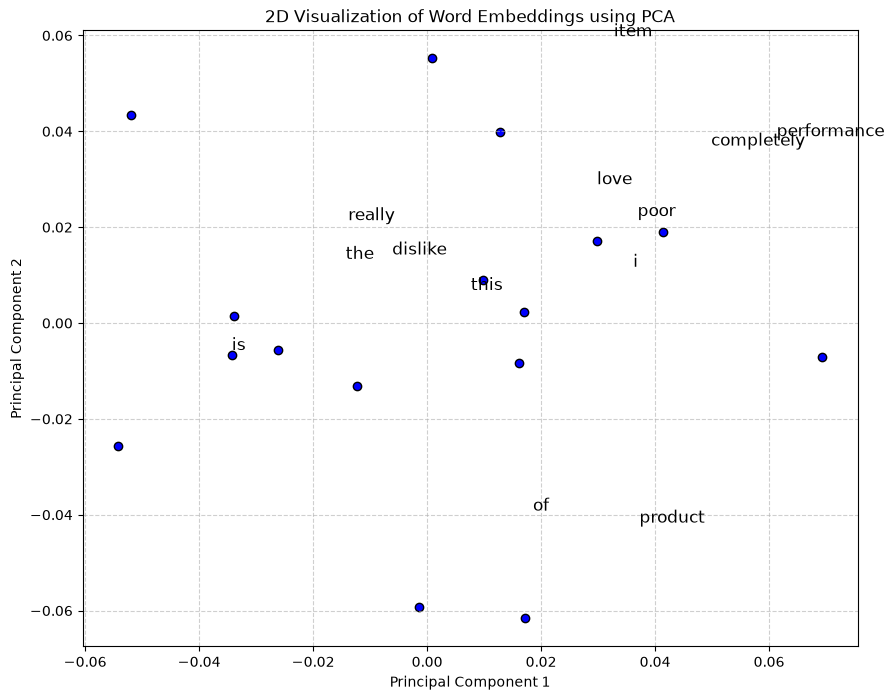

In [8]:
embedding_weights = model.layers[0].get_weights()[0]

# Exclude the 0th index because it is strictly reserved for padding
words = list(word_index.keys())
word_vectors = embedding_weights[1:] 

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

print("\n--- 8. Plotting PCA Visualization ---")
plt.figure(figsize=(10, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c='blue', edgecolors='k')

for i, word in enumerate(words):
    plt.annotate(word, (reduced_vectors[i, 0] + 0.02, reduced_vectors[i, 1] + 0.02), fontsize=12)

plt.title('2D Visualization of Word Embeddings using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()